# EDA-PREPROCESO-MODELACIONES TFM

In [1]:
# libraries
import pandas as pd
import numpy as np
import functools as ft
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
# modelacion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
# encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# seleccion de modelos
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)

#otros
import time
import warnings
warnings.filterwarnings('ignore')

## Carga de datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


dt_librosa = pd.read_csv("/content/drive/MyDrive/Master/tfm_models/data_aumentada_v1.csv", index_col=0) # mejor opcion

dt_librosa.head()

,duracion_s,rms_mean,rms_std,dementia,dementia type,gender,ethnicity,f0_mean,f0_std,f0_range,...,propn_ratio,noun_pron_ratio,syntax_depth,std_words_per_sent,mean_word_length,std_word_length,function_ratio,duration,pause_prob,wpm
0,71.019688,0.071390,0.050389,1,Alzheimer,male,Caucasian/White,174.444418,51.103025,311.055420,...,0.037975,0.465517,7.666667,75.330383,3.789030,2.132184,0.611814,72.76,0.263634,195.437053
1,47.000000,0.144582,0.090372,1,Dementia,female,Black/African American,292.169978,115.242586,659.783615,...,0.000000,0.500000,5.500000,13.379088,3.810811,1.850315,0.628378,47.04,0.122493,188.775510
2,38.000000,0.123960,0.079574,1,Dementia,female,Black/African American,238.856939,58.060892,352.463261,...,0.000000,0.655172,5.428571,12.290697,3.625000,1.952562,0.585938,38.40,0.000328,200.000000
3,90.000000,0.061281,0.049997,1,Dementia,female,Black/African American,255.297147,68.547493,638.292396,...,0.000000,1.146341,5.357143,9.598044,4.003597,2.092292,0.575540,89.00,0.002673,187.415730
4,55.000000,0.060310,0.051383,1,Dementia,male,Caucasian/White,134.696479,38.961565,243.928633,...,0.067073,1.000000,4.500000,8.890444,4.286585,2.216252,0.640244,55.00,0.149834,178.909091


In [4]:
dt_librosa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5353 entries, 0 to 5352
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   duracion_s                                  5353 non-null   float64
 1   rms_mean                                    5353 non-null   float64
 2   rms_std                                     5353 non-null   float64
 3   dementia                                    5353 non-null   int64  
 4   dementia type                               5218 non-null   object 
 5   gender                                      5216 non-null   object 
 6   ethnicity                                   5216 non-null   object 
 7   f0_mean                                     5353 non-null   float64
 8   f0_std                                      5353 non-null   float64
 9   f0_range                                    5353 non-null   float64
 10  articulation_rate

In [5]:
dt_librosa.describe()

,duracion_s,rms_mean,rms_std,dementia,f0_mean,f0_std,f0_range,articulation_rate,silence_segments_n,silence_dur_mean_s,...,propn_ratio,noun_pron_ratio,syntax_depth,std_words_per_sent,mean_word_length,std_word_length,function_ratio,duration,pause_prob,wpm
count,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,...,5352.000000,5.352000e+03,5352.000000,5335.000000,5352.000000,5352.000000,5352.000000,5.353000e+03,5353.000000,5353.000000
mean,56.052795,0.088644,0.061518,0.474874,175.572451,47.088001,291.178833,1.846106,53.917613,0.276751,...,0.069087,1.228510e+11,4.629553,10.720466,3.944274,2.112382,0.606501,5.585990e+01,0.191949,166.157261
std,26.642870,0.034260,0.017562,0.499415,61.556335,27.496927,174.764403,0.332913,26.983720,0.094880,...,0.136089,1.369861e+12,1.610823,8.823151,0.262636,0.249231,0.065034,2.661328e+01,0.148625,33.333275
min,6.000000,0.015588,0.018439,0.000000,67.656431,8.965921,54.549459,0.894813,6.000000,0.114798,...,-0.003861,-6.462964e+10,1.909091,0.000000,3.171053,1.200907,0.400000,1.000000e-12,-0.001965,0.000000
25%,32.915443,0.062975,0.049632,0.000000,139.096063,32.280100,194.185516,1.631988,31.995471,0.206974,...,0.016976,-1.180022e+10,3.712882,6.759743,3.767543,1.961185,0.575111,3.291534e+01,0.075387,142.113990
50%,51.455945,0.082746,0.060235,0.000000,162.582390,41.471919,246.911969,1.851132,51.426369,0.252212,...,0.036387,8.722826e-01,4.295817,8.752268,3.908447,2.083980,0.600143,5.140295e+01,0.160504,165.839149
75%,85.000000,0.110745,0.072020,1.000000,197.763060,53.452868,325.323063,2.073582,68.967229,0.330958,...,0.062625,1.194686e+10,5.077766,11.720955,4.097857,2.253731,0.619947,8.439006e+01,0.275741,188.047154
max,162.003750,0.235701,0.134006,1.000000,1831.478764,413.196969,1795.411759,3.815631,173.000000,0.775724,...,0.850746,3.100000e+13,16.000000,98.000000,5.282051,3.571648,0.948814,1.616800e+02,0.825826,300.538278


In [6]:
dt_librosa.dementia.value_counts(normalize=True)

,proportion
dementia,
0,0.525126
1,0.474874


## Preprocesamiento

### Valores perdidos-imputaciones

In [13]:
dt_librosa.isnull().sum()

,0
duracion_s,0
rms_mean,0
rms_std,0
dementia,0
dementia type,135
...,...
std_word_length,0
function_ratio,1
duration,0
pause_prob,0


In [8]:
dt_librosa.gender.value_counts()

,count
gender,
male,2572
Unknown,1855
female,789


In [9]:
# porcentaje de valores perdidos
dt_librosa['gender'].isnull().sum()/len(dt_librosa) * 100

np.float64(2.5593125350270878)

In [ ]:
# eliminar los valores perdidos
dt_librosa = dt_librosa.dropna()

In [11]:
def imputation_nas(df, var):
    df[var] = df[var].fillna(df[var].median())
    return df[var]


In [12]:
imputation_nas(dt_librosa, 'std_word_length')

,std_word_length
0,2.132184
1,1.850315
2,1.952562
3,2.092292
4,2.216252
...,...
5348,1.921394
5349,2.311762
5350,2.194336
5351,1.982055


In [14]:
imputation_nas(dt_librosa, 'function_ratio')

,function_ratio
0,0.611814
1,0.628378
2,0.585938
3,0.575540
4,0.640244
...,...
5348,0.626588
5349,0.576603
5350,0.534689
5351,0.589977


In [15]:
# Identificar columnas categóricas
cat_cols = dt_librosa.select_dtypes(include=['object', 'category']).columns.tolist()
# calcular la moda para cada columna categorica
modas = {}
for col in cat_cols:
    moda = dt_librosa[col].mode()
    if not moda.empty:
        modas[col] = moda[0]
        print(f"{col}: Moda = '{modas[col]}' ({dt_librosa[col].isna().sum()} nulos a reemplazar)")
    else:
        modas[col] = None
        print(f"{col}: No hay moda, todos los valores son NAN's")

# imputar valores nulos
dt_librosa = dt_librosa.copy()
for col, moda_valor in modas.items():
    if moda_valor is not None:
        # contal nulos antes y despues
        nulos_antes = dt_librosa[col].isna().sum()
        dt_librosa[col] = dt_librosa[col].fillna(moda_valor)
        nulos_despues = dt_librosa[col].isna().sum()

        print(f"{col}: {nulos_antes}→ {nulos_despues} nulos ")

dementia type: Moda = 'Unknown' (135 nulos a reemplazar)
gender: Moda = 'male' (137 nulos a reemplazar)
ethnicity: Moda = 'Caucasian/White' (137 nulos a reemplazar)
dementia type: 135→ 0 nulos 
gender: 137→ 0 nulos 
ethnicity: 137→ 0 nulos 


In [18]:
mlldt_librosa.isnull().sum()

,0
duracion_s,0
rms_mean,0
rms_std,0
dementia,0
dementia type,0
...,...
std_word_length,0
function_ratio,0
duration,0
pause_prob,0


In [19]:
dt_librosa.columns

Index(['duracion_s', 'rms_mean', 'rms_std', 'dementia', 'dementia type',
       'gender', 'ethnicity', 'f0_mean', 'f0_std', 'f0_range',
       'articulation_rate', 'silence_segments_n', 'silence_dur_mean_s',
       'silence_ratio_rms', 'silence_dur_std_s', 'silence_dur_max_s',
       'speech_rate', 'voiced_dur_mean_s', 'voiced_segments_n', 'voiced_ratio',
       'voiced_dur_cv', 'F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'jitterLocal_sma3nz_amean',
       'shimmerLocaldB_sma3nz_amean', 'HNRdBACF_sma3nz_amean',
       'alphaRatioV_sma3nz_amean', 'hammarbergIndexV_sma3nz_amean',
       'slopeV0-500_sma3nz_amean', 'slopeV500-1500_sma3nz_amean',
       'VoicedSegmentsPerSec', 'MeanVoi

In [20]:
#dt_lib = dt_librosa[['duracion_s', 'rms_mean', 'rms_std', 'dementia',
#       'gender', 'ethnicity',  'f0_mean',
#       'f0_std', 'f0_range', 'articulation_rate', 'silence_segments_n',
#       'silence_dur_mean_s', 'silence_ratio_rms', 'silence_dur_std_s',
#       'silence_dur_max_s', 'speech_rate', 'voiced_dur_mean_s',
#       'voiced_segments_n', 'voiced_ratio', 'voiced_dur_cv']]

#dt_lib.head()
dt_lib = dt_librosa.drop("dementia type", axis=1)

In [21]:
# dimensiones datos
dt_lib.shape

(5353, 73)

In [22]:
# revisar variable dependiente
dt_lib.dementia.value_counts(normalize=True)

,proportion
dementia,
0,0.525126
1,0.474874


### Transformaciones

In [23]:
# genero
dt_lib.gender.value_counts()

,count
gender,
male,2709
Unknown,1855
female,789


In [ ]:
#crear y ajustar el encoder
#label_encoder = LabelEncoder()
#dt_lib['gender'] = label_encoder.fit_transform(dt_lib['gender'])
#dt_lib['ethnicity'] = label_encoder.fit_transform(dt_lib['ethnicity'])

In [24]:
# gender
encoded_df = pd.get_dummies(dt_lib[['gender']], prefix='gender', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [25]:
#ethnicity
encoded_df = pd.get_dummies(dt_lib[['ethnicity']], prefix='ethnicity', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [26]:
dt_lib = dt_lib.drop(['gender', 'ethnicity'], axis=1)

In [27]:
dt_lib.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5353 entries, 0 to 5352
Data columns (total 78 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   duracion_s                                  5353 non-null   float64
 1   rms_mean                                    5353 non-null   float64
 2   rms_std                                     5353 non-null   float64
 3   dementia                                    5353 non-null   int64  
 4   f0_mean                                     5353 non-null   float64
 5   f0_std                                      5353 non-null   float64
 6   f0_range                                    5353 non-null   float64
 7   articulation_rate                           5353 non-null   float64
 8   silence_segments_n                          5353 non-null   float64
 9   silence_dur_mean_s                          5353 non-null   float64
 10  silence_ratio_rms

### Normalizacion

In [28]:
# Min-Max
scaler_minmax = MinMaxScaler()
num_cols = dt_lib.iloc[:, 1:].select_dtypes(include=['int64', 'float64']).columns
dt_lib[num_cols] = scaler_minmax.fit_transform(dt_lib[num_cols])
dt_lib.describe()

,duracion_s,rms_mean,rms_std,dementia,f0_mean,f0_std,f0_range,articulation_rate,silence_segments_n,silence_dur_mean_s,...,propn_ratio,noun_pron_ratio,syntax_depth,std_words_per_sent,mean_word_length,std_word_length,function_ratio,duration,pause_prob,wpm
count,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000,...,5352.000000,5352.000000,5352.000000,5335.000000,5352.000000,5353.000000,5353.000000,5353.000000,5353.000000,5353.000000
mean,56.052795,0.331902,0.372757,0.474874,0.061183,0.094308,0.135927,0.325694,0.286932,0.245040,...,0.085359,0.006035,0.193065,0.109393,0.366282,0.384466,0.376265,0.345497,0.234254,0.552866
std,26.642870,0.155649,0.151967,0.499415,0.034899,0.068023,0.100390,0.113979,0.161579,0.143556,...,0.159241,0.044097,0.114316,0.090032,0.124413,0.105118,0.118488,0.164605,0.179544,0.110912
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.915443,0.215283,0.269914,0.000000,0.040503,0.057675,0.080211,0.252386,0.155662,0.139465,...,0.024383,0.001701,0.128011,0.068977,0.282563,0.320699,0.319076,0.203583,0.093443,0.472865
50%,51.455945,0.305106,0.361658,0.000000,0.053818,0.080414,0.110498,0.327415,0.272014,0.207912,...,0.047096,0.002080,0.169381,0.089309,0.349311,0.372488,0.364683,0.317930,0.196268,0.551807
75%,85.000000,0.432312,0.463638,1.000000,0.073764,0.110053,0.155540,0.403575,0.377049,0.327056,...,0.077797,0.002465,0.224874,0.119602,0.439036,0.444091,0.400762,0.521957,0.335478,0.625701
max,162.003750,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# eliminar los valores perdidos
dt_lib = dt_lib.dropna()

## Modelos

In [34]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(5335, 77)

y shape:(5335,)
n Distribucion de clases:
dementia
0.0    0.525211
1.0    0.474789
Name: proportion, dtype: float64


In [35]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (3734, 77)
Test set: (1601, 77)

Churn en train: 47.5%
Churn en test: 47.5%


## Seleccion de caracteristicas

In [36]:
# SelectKBest con Anova F-test

k_best = 30
selector_kbest = SelectKBest(score_func=f_classif, k=k_best)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)

print('FILTER METHOD: SelectKBest (ANOVA F-test)')
print('='*60)
print(f'K (features seleccionadas): {k_best}')
print(f'Features originales: {X_train.shape[1]}')
print(f'Features seleccionadas: {X_train_kbest.shape[1]}')

# obtener los scores
feature_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selector_kbest.scores_
}).sort_values('score', ascending=False)

print(f"\nTop {k_best} features por score F:")
print(feature_scores.head(k_best))

# Entrenar el modelo
model_kbest = RandomForestClassifier(n_estimators=100, random_state=42)
model_kbest.fit(X_train_kbest, y_train)
y_pred_kbest = model_kbest.predict(X_test_kbest)
accuracy_kbest = accuracy_score(y_test, y_pred_kbest)
print(f"\nAccuracy con selectKBest: {accuracy_kbest:.4f}")

FILTER METHOD: SelectKBest (ANOVA F-test)
K (features seleccionadas): 30
Features originales: 77
Features seleccionadas: 30

Top 30 features por score F:
                                       feature       score
76                           ethnicity_Unknown  487.255433
73                   ethnicity_Caucasian/White  232.605233
71                                 gender_male  199.390730
70                               gender_female   66.422760
59                                  pron_ratio   56.700665
4                                       f0_std   55.792634
69                                         wpm   48.346828
20  F0semitoneFrom27.5Hz_sma3nz_percentile50.0   40.699045
17           F0semitoneFrom27.5Hz_sma3nz_amean   40.281065
21  F0semitoneFrom27.5Hz_sma3nz_percentile80.0   39.779656
62                                syntax_depth   35.950909
75               ethnicity_Indian Subcontinent   35.532064
31                 slopeV500-1500_sma3nz_amean   34.230429
64                  

In [37]:
# Recursive Feature Elimination (RFE)

n_features_rfe = 15
estimator = LogisticRegression(max_iter=1000, random_state=23)
selector_rfe = RFE(estimator, n_features_to_select=n_features_rfe, step=1)
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
X_test_rfe = selector_rfe.transform(X_test)

print(f"Wrapper Method: Recursive Feature Elimination")
print(f"="*80)
print(f"Features seleccionadas: {n_features_rfe}")

# selecciondo features con su rankings
feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'selected': selector_rfe.support_,
    'ranking': selector_rfe.ranking_
}).sort_values('ranking')

print("\nFeatures seleccionadas (ranking=1):")
print(list(feature_ranking[feature_ranking['ranking'] ==1]['feature']))

# entrenar al modelo
model_rfe = RandomForestClassifier(n_estimators=100, random_state=23)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)
print(f"\nAccuracy con RFE:{accuracy_rfe:.4f}")

Wrapper Method: Recursive Feature Elimination
Features seleccionadas: 15

Features seleccionadas (ranking=1):
['rms_std', 'f0_std', 'silence_dur_std_s', 'voiced_dur_cv', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'slopeV500-1500_sma3nz_amean', 'n_advs', 'unvoiced_seg_cv', 'n_sents', 'n_prons', 'adv_ratio', 'n_adjs', 'gender_male', 'gender_female', 'duration']

Accuracy con RFE:0.8726


\Embedded method: Feature importance

Top 20 features mas impornates:
                                       feature  importance
76                           ethnicity_Unknown    0.039467
4                                       f0_std    0.020960
69                                         wpm    0.018645
71                                 gender_male    0.018580
68                                  pause_prob    0.018197
31                 slopeV500-1500_sma3nz_amean    0.018167
51                         mean_words_per_sent    0.017241
18      F0semitoneFrom27.5Hz_sma3nz_stddevNorm    0.016761
59                                  pron_ratio    0.016616
5                                     f0_range    0.016031
24                    loudness_sma3_stddevNorm    0.015568
34                StddevVoicedSegmentLengthSec    0.015330
57                                   adj_ratio    0.015216
73                   ethnicity_Caucasian/White    0.015213
62                                syntax_dept

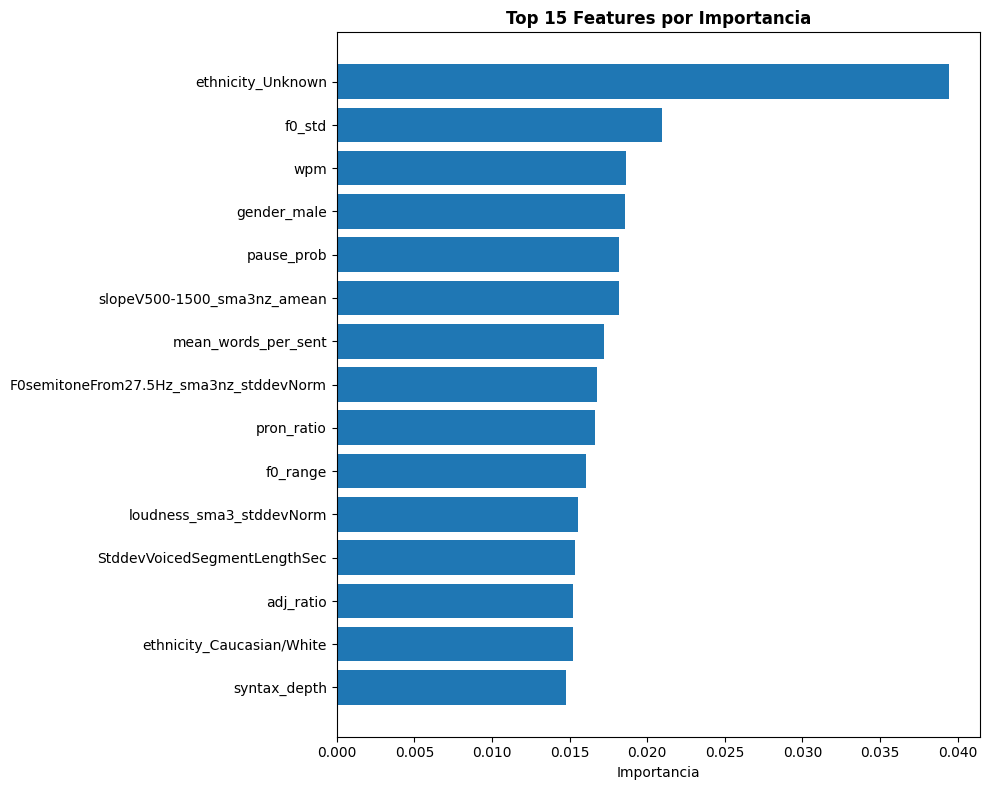

In [38]:
## Feature importance

rf_importance = RandomForestClassifier(n_estimators=100, random_state=23)
rf_importance.fit(X_train, y_train)

#obtener importancia
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\Embedded method: Feature importance")
print("="*80)
print(f"\nTop 20 features mas impornates:")
print(importances.head(20))

# visualizaciones
plt.figure(figsize=(10,8))
top_n = 15
plt.barh(range(top_n), importances['importance'].head(top_n))
plt.yticks(range(top_n), importances['feature'].head(top_n))
plt.xlabel('Importancia')
plt.title(f"Top {top_n} Features por Importancia", fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Seleccion de caracteristicas para los modelos

In [39]:
dt_lib = dt_lib[['n_sents', 'n_adjs', 'slopeV500-1500_sma3nz_amean', 'n_prons', 'f0_std', 'f0_range',
                 'articulation_rate', 'silence_segments_n', 'gender_male', 'gender_female', 'silence_dur_std_s',
                 'F0semitoneFrom27.5Hz_sma3nz_amean', 'voiced_dur_cv', 'voiced_dur_mean_s', 'duration','dementia']]


In [40]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(5335, 15)

y shape:(5335,)
n Distribucion de clases:
dementia
0.0    0.525211
1.0    0.474789
Name: proportion, dtype: float64


In [41]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (3734, 15)
Test set: (1601, 15)

Churn en train: 47.5%
Churn en test: 47.5%


In [42]:
y_train

,dementia
1325,0.0
2747,0.0
5331,0.0
1777,1.0
44,1.0
...,...
162,0.0
1232,1.0
2888,0.0
1012,0.0


### Balanceo de datos

In [ ]:
#from imblearn.over_sampling import SMOTE

# Inicializar SMOTE con parámetros adecuados para un dataset pequeño
#smote = SMOTE(
#    random_state=42,
#    k_neighbors=3,  # Reducir vecinos porque tenemos pocos datos
#    sampling_strategy=0.80  # Aumentar la clase minoritaria al 60% de la mayoritaria (no necesariamente 50-50)
#)

# Aplicar SMOTE solo a los datos de entrenamiento
#X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Verificar la nueva distribución
#print("Distribución después de SMOTE:")
#print(pd.Series(y_resampled).value_counts())
#print(pd.Series(y_resampled).value_counts(normalize=True))

# Modelos

## Neural Networks

In [43]:
from sklearn.metrics import log_loss # entropía cruzada

max_iter = 100

# Hago explícitamente la partición interna que hace sklearn en training y test:
X_train2, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train,
                                      test_size=0.2, random_state=1)



In [84]:
from keras.models import Sequential
from IPython.display import clear_output
from time import sleep
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense
from keras.regularizers import L1, L2
from keras.optimizers import Adam

model = Sequential()

model.add(Dense(64, input_shape=(X_train2.shape[1],), activation='relu', kernel_regularizer=L1(0.1)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # la neurona de salida estima la probabilidad de que sea 1

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['f1_score'])

In [85]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,297 (28.50 KB)

 Trainable params: 7,297 (28.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# L1: loss total = log_loss + alpha*suma(abs(pesos))
# L2: loss total = log_loss + alpha*suma(pesos^2)


In [86]:
ruta = "nnet.keras"
losses_val = []
losses_tr  = []

max_iter = 100

callbacks = [ModelCheckpoint(filepath=ruta, monitor="val_loss", verbose=1,
                             save_best_only=True)]



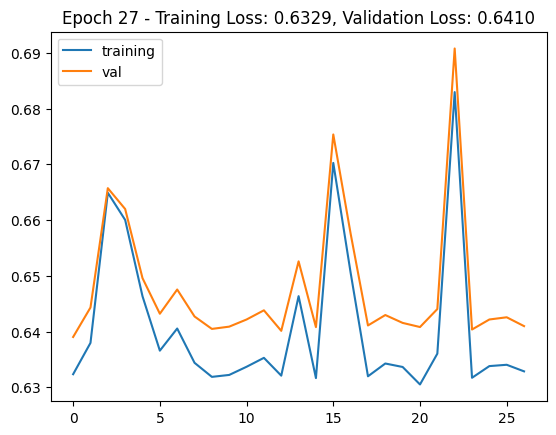


Epoch 1: val_loss did not improve from 0.66765


In [ ]:
for epoca in range(max_iter):
    history = model.fit(X_train2, y_train, epochs=1,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0) # entreno solo 1 época en training

    # The log_loss expects probabilities, and model.predict() outputs probabilities with sigmoid activation
    loss_val = log_loss(y_val, model.predict(X_val, verbose=0))
    loss_tr  = log_loss(y_train, model.predict(X_train2, verbose=0))

    losses_val.append(loss_val)
    losses_tr.append(loss_tr)
    clear_output(wait=True)
    plt.plot(losses_tr, label="training")
    plt.plot(losses_val, label="val")
    plt.legend()
    plt.title(f"Epoch {epoca+1} - Training Loss: {loss_tr:.4f}, Validation Loss: {loss_val:.4f}")
    plt.show()
    sleep(0.1)

print("Training complete. Best model saved to", ruta)

In [74]:
#from keras.models import load_model

model = load_model(ruta)


In [75]:
umbral = 0.5
clase_predicha = (1*model.predict(X_test)>umbral).flatten()
(clase_predicha == y_test.values).mean()

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float64(0.7314178638351031)

In [76]:
umbral = 0.5
clase_predicha = (1*model.predict(X_train2)>umbral).flatten()
(clase_predicha == y_train.values).mean()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


np.float64(0.7231335788416471)

In [77]:
# evaluate the model
y_pred_train = (model.predict(X_train2) > 0.5).astype(int)
y_pred_test = (model.predict(X_test) > 0.5).astype(int)

cm_train = confusion_matrix(y_train, y_pred_train)
report_train = classification_report(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)
report_test = classification_report(y_test, y_pred_test)

print("Evaluation model en train")
print("Confusion Matrix (Train):\n", cm_train)
print("\nClassification Report (Train):\n", report_train)
print("=" * 100)
print("Evaluation model en test")
print("\nConfusion Matrix (Test):\n", cm_test)
print("\nClassification Report (Test):\n", report_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Evaluation model en train
Confusion Matrix (Train):
 [[1201  368]
 [ 459  959]]

Classification Report (Train):
               precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      1569
         1.0       0.72      0.68      0.70      1418

    accuracy                           0.72      2987
   macro avg       0.72      0.72      0.72      2987
weighted avg       0.72      0.72      0.72      2987

Evaluation model en test

Confusion Matrix (Test):
 [[651 190]
 [240 520]]

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.73      0.77      0.75       841
         1.0       0.73      0.68      0.71       760

    accuracy                           0.73      1601
   macro avg       0.73      0.73      0.73      1601
weighted avg       0.73      0.73      0.73      1601



## Dos neuronas de salida

In [ ]:
from keras.models import Sequential

from keras.layers import Dense
from keras.regularizers import L1, L2

model2 = Sequential()

model2.add(Dense(64, input_shape=(X_train_est.shape[1],), activation='relu', kernel_regularizer=L1(0.01)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(2, activation='softmax')) # la neurona 0 estima la proba de clase 0 y la 1 la de clase 1

model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [ ]:
ruta2 = "nnet2.keras"
losses_val = []
losses_tr  = []

max_iter = 100

callbacks = [ModelCheckpoint(filepath=ruta2, monitor="val_loss", verbose=1,
                             save_best_only=True)]

for epoca in range(max_iter):
    history = model2.fit(X_train2, y_train, epochs=1,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0) # entreno solo 1 época en training

    # The log_loss expects probabilities, and model.predict() outputs probabilities with sigmoid activation
    loss_val = log_loss(y_val, model2.predict(X_val, verbose=0))
    loss_tr  = log_loss(y_train2, model2.predict(X_train2, verbose=0))

    losses_val.append(loss_val)
    losses_tr.append(loss_tr)
    clear_output(wait=True)
    plt.plot(losses_tr, label="training")
    plt.plot(losses_val, label="val")
    plt.legend()
    plt.title(f"Epoch {epoca+1} - Training Loss: {loss_tr:.4f}, Validation Loss: {loss_val:.4f}")
    plt.show()
    sleep(0.1)

In [ ]:
from keras.models import load_model

model2 = load_model(ruta2)

In [ ]:
clase_predicha = np.argmax(model2.predict(X_train_est), axis=1) # por cada fila, me dice que columna es la mayor, me dice la clase

In [ ]:
umbral = 0.5

(clase_predicha == y_train2.values).mean()

In [ ]:

clase_predicha = np.argmax(model2.predict(X_val_est), axis=1)
(clase_predicha == y_val2.values).mean()